In [1]:
import sys
import os

module_path = os.path.abspath(os.path.join('../utils'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [6]:
import numpy as np 
from scipy import sparse 
from scipy import fft
from scipy.linalg import expm
from matplotlib import pyplot as plt
from matplotlib import animation
from time import time

from ETD_solver import cheb

Adapt the MatLab code from Trefethen for solving the Allen-Cahn equation:
$$u_t = 0.01*u_{xx} + u - u^3$$
for $x \in [-1, 1]$ with $u(-1) = -1, u(1) = 1$.

In [63]:
def allen_cahn(N):

    sl = np.s_[1:-1]
    # spatial grid and initial condition
    D, x_full = cheb(N)
    x = x_full[sl]
    w = 0.53 * x + 0.47 * np.sin(-1.5 * np.pi * x)      # initial condition
    w -= x                                              # subtract off x to make BC's homogenous
    u = np.concatenate([[-1], w + x, [1]])              # I think my cheb function is backwards w respect to Trefethen's

    # precompute ETD-RK4 matrix quantities
    h = 0.25                           # time step
    M = 32                             # number of points for resolvent integral
    r = 15. * np.exp(1j * np.pi * (np.arange(1, M+1) - 0.5) / M)        # points along complex circle
    
    
    L = D @ D                       # linear operator
    L = 0.01 * L[sl, sl]             # 2nd order differentiation
    A = h * L 
    E = expm(A).astype(complex)
    E2 = expm(A / 2).astype(complex)
    I = np.eye(N-1) .astype(complex)
    Z = np.zeros((N-1, N-1)).astype(complex)
    f1 = np.zeros((N-1, N-1)).astype(complex)
    f2 = np.zeros((N-1, N-1)).astype(complex)
    f3 = np.zeros((N-1, N-1)).astype(complex)
    Q = np.zeros((N-1, N-1)).astype(complex)
    for j in range(M):
        z = r[j]
        zIA = np.linalg.inv(z*I - A)
        Q += h * zIA * (np.exp(z / 2.) - 1.)
        f1 += h * zIA * (-4. - z + np.exp(z) * (4. - 3. * z + z**2)) / z**2
        f2 += h * zIA * (2. + z + np.exp(z) * (z - 2.)) / z**2
        f3 += h * zIA * (-4. - 3. * z - z**2 + np.exp(z) * (4. - z)) / z**2
    f1 = np.real(f1 / M)
    f2 = np.real(f2 / M)
    f3 = np.real(f3 / M)
    Q = np.real(Q / M)
    
    # main time-stepping loop
    print(f"Starting to time-step!")
    uu = u 
    tt = [0]
    tmax = 70 
    nmax = int(np.round(tmax / h))
    nplt = int(np.floor((tmax / 70) / h))
    for n in range(1, nmax+1):
        t = n * h 
        print(t)
        Nu = (w + x) - (w + x)**3 
        a = E2 @ w + Q @ Nu 
        Na = a + x - (a + x)**3 
        b = E2 @ w + Q @ Na
        Nb = b + x - (b + x)**3 
        c = E2 @ a + Q @ (2. * Nb - Nu)
        Nc = c + x - (c + x)**3
        w = E @ w + f1 @ Nu + 2. * f2 @ (Na + Nb) + f3 @ Nc 

        if n % nplt == 0:
            u = np.concatenate([[-1], w + x, [1]])
            uu = np.vstack((uu, u))
            tt.append(t)

    return uu, np.array(tt), x_full

In [64]:
u, t, x = allen_cahn(20)

Starting to time-step!
0.25
0.5
0.75
1.0
1.25
1.5
1.75
2.0
2.25
2.5
2.75
3.0
3.25
3.5
3.75
4.0
4.25
4.5
4.75
5.0
5.25
5.5
5.75
6.0
6.25
6.5
6.75
7.0
7.25
7.5
7.75
8.0
8.25
8.5
8.75
9.0
9.25
9.5
9.75
10.0
10.25
10.5
10.75
11.0
11.25
11.5
11.75
12.0
12.25
12.5
12.75
13.0
13.25
13.5
13.75
14.0
14.25
14.5
14.75
15.0
15.25
15.5
15.75
16.0
16.25
16.5
16.75
17.0
17.25
17.5
17.75
18.0
18.25
18.5
18.75
19.0
19.25
19.5
19.75
20.0
20.25
20.5
20.75
21.0
21.25
21.5
21.75
22.0
22.25
22.5
22.75
23.0
23.25
23.5
23.75
24.0
24.25
24.5
24.75
25.0
25.25
25.5
25.75
26.0
26.25
26.5
26.75
27.0
27.25
27.5
27.75
28.0
28.25
28.5
28.75
29.0
29.25
29.5
29.75
30.0
30.25
30.5
30.75
31.0
31.25
31.5
31.75
32.0
32.25
32.5
32.75
33.0
33.25
33.5
33.75
34.0
34.25
34.5
34.75
35.0
35.25
35.5
35.75
36.0
36.25
36.5
36.75
37.0
37.25
37.5
37.75
38.0
38.25
38.5
38.75
39.0
39.25
39.5
39.75
40.0
40.25
40.5
40.75
41.0
41.25
41.5
41.75
42.0
42.25
42.5
42.75
43.0
43.25
43.5
43.75
44.0
44.25
44.5
44.75
45.0
45.25
45.5
45.75
46.0
46.2

In [66]:
print(t)

[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35.
 36. 37. 38. 39. 40. 41. 42. 43. 44. 45. 46. 47. 48. 49. 50. 51. 52. 53.
 54. 55. 56. 57. 58. 59. 60. 61. 62. 63. 64. 65. 66. 67. 68. 69. 70.]


/mnt/c/Users/tiara/Desktop/MATH511/Exponential_Time_Differencing/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


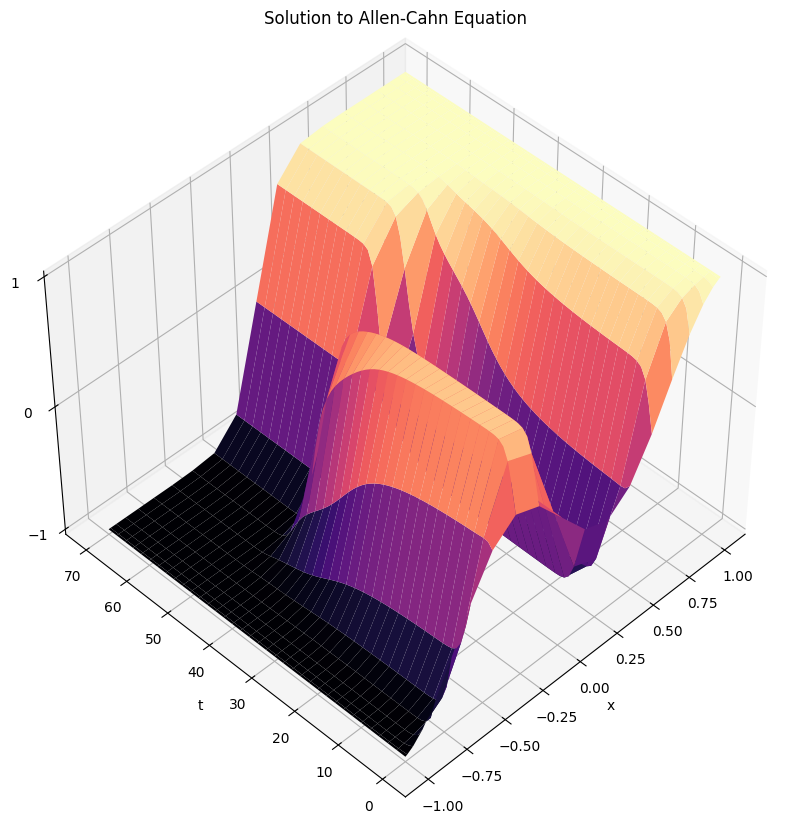

In [61]:
# plot as a 3D surface 
X, T = np.meshgrid(x, t)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(X, T, u, cmap="magma")
ax.view_init(elev=45, azim=(-45 - 90))
ax.set_zticks([-1, 0, 1])
ax.set_xlabel("x")
ax.set_ylabel("t")
ax.set_zlabel("u")
ax.set_title("Solution to Allen-Cahn Equation")
plt.show()

In [62]:
print(t)

[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35.
 36. 37. 38. 39. 40. 41. 42. 43. 44. 45. 46. 47. 48. 49. 50. 51. 52. 53.
 54. 55. 56. 57. 58. 59. 60. 61. 62. 63. 64. 65. 66. 67. 68. 69. 70.]


In [35]:
print(u.shape, t.shape, x.shape)

(71, 21) (71,) (21,)


/mnt/c/Users/tiara/Desktop/MATH511/Exponential_Time_Differencing/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/mnt/c/Users/tiara/Desktop/MATH511/Exponential_Time_Differencing/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


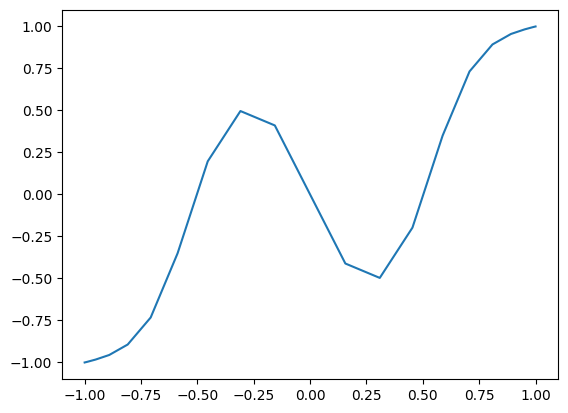

In [46]:
plt.plot(x, u[1])
plt.show()